# Baseline Clause Classifier
---
## Phase 1 — Load Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\chari\Desktop\Contract_Intelligence_AI\data\processed\clause_classification_dataset.csv")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

DATASET LOADED SUCCESSFULLY


### 1.1 — Inspect Shape

In [2]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

Shape: (2040, 3)
Rows: 2040
Columns: 3

Column Names: ['text', 'label_name', 'target']

Data Types:
text          object
label_name    object
target         int64
dtype: object


### 1.2 — Inspect Labels

In [3]:
print("Label Distribution:\n")
print(df['label_name'].value_counts())
print(f"\nUnique Labels: {df['label_name'].nunique()}")
print(f"\nTarget Distribution:\n{df['target'].value_counts()}")
print(f"\nTarget Ratio (1s): {df['target'].mean():.2%}")

Label Distribution:

label_name
Renewal Term                   510
Termination For Convenience    510
Uncapped Liability             510
Cap On Liability               510
Name: count, dtype: int64

Unique Labels: 4

Target Distribution:
target
0    1295
1     745
Name: count, dtype: int64

Target Ratio (1s): 36.52%


### 1.3 — Check for Nulls

In [4]:
print("Null Values per Column:\n")
print(df.isnull().sum())
print(f"\nTotal Nulls: {df.isnull().sum().sum()}")

Null Values per Column:

text          0
label_name    0
target        0
dtype: int64

Total Nulls: 0


### 1.4 — Sample Rows

In [5]:
pd.set_option('display.max_colwidth', 100)
df.head(10)

,text,label_name,target
0,"nt shall be ten (10) years (the ""Term"") which shall commence on the date upon which the Company ...",Renewal Term,1
1,"wo, the expectation for year two will have been met, but there will be no carry-over to year thr...",Termination For Convenience,0
2,Appointment. The Company appoints the Distributor as an exclusive distributor of Products in the...,Uncapped Liability,0
3,"nder shall be free from defects in design, materials and workmanship for a period of twenty-four...",Cap On Liability,0
4,"ime the relevant liability is to be assessed (the ""Applicable Time""), it shall be calculated on ...",Renewal Term,0
5,ve Google a reasonable time to fix the problem and (if necessary) to supply Distributor with a c...,Termination For Convenience,0
6,"'s liability under Clause 10 (Indemnities), or Distributor's liability under Clause 2 (License G...",Uncapped Liability,1
7,"'s liability under Clause 10 (Indemnities), or Distributor's liability under Clause 2 (License G...",Cap On Liability,1
8,"is commissioned the buyer. 5. PACKING: To be packed in new strong wooden case(s) /carton(s), sui...",Renewal Term,0
9,"s forward amendments or not accept orders, the seller shall be in the form of a written notice t...",Termination For Convenience,0


### 1.5 — Text Length Analysis

In [6]:
df['text_length'] = df['text'].str.len()
print("Text Length Statistics (characters):")
print(df['text_length'].describe())

Text Length Statistics (characters):
count    2040.000000
mean      637.945588
std       253.577964
min       461.000000
25%       500.000000
50%       500.000000
75%       718.000000
max      3253.000000
Name: text_length, dtype: float64


---
## Phase 2 — Train/Test Split (80/20)

In [7]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN/TEST SPLIT COMPLETE")
print("=" * 60)
print(f"\nTraining set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})")
print(f"Test set:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

TRAIN/TEST SPLIT COMPLETE

Training set:  1632 samples (80%)
Test set:      408 samples (20%)

Training target distribution:
target
0    1036
1     596
Name: count, dtype: int64

Test target distribution:
target
0    259
1    149
Name: count, dtype: int64


---
## Phase 3 — TF-IDF Vectorization
Convert text to numerical features so the model can "see" text.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("=" * 60)
print("TF-IDF VECTORIZATION COMPLETE")
print("=" * 60)
print(f"\nVocabulary Size: {len(tfidf.vocabulary_)}")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Test Matrix Shape:     {X_test_tfidf.shape}")
print(f"\nTop 20 Features (by IDF):")
feature_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_
top_idx = np.argsort(idf_scores)[:20]
for i in top_idx:
    fname = feature_names[i]
    print(f"  {fname:30s} IDF={idf_scores[i]:.4f}")

TF-IDF VECTORIZATION COMPLETE

Vocabulary Size: 10000
Training Matrix Shape: (1632, 10000)
Test Matrix Shape:     (408, 10000)

Top 20 Features (by IDF):
  agreement                      IDF=1.4107
  shall                          IDF=1.4638
  party                          IDF=1.8161
  parties                        IDF=2.3344
  section                        IDF=2.4475
  date                           IDF=2.4739
  notice                         IDF=2.5038
  including                      IDF=2.5261
  written                        IDF=2.5374
  termination                    IDF=2.5575
  term                           IDF=2.5811
  event                          IDF=2.6236
  provided                       IDF=2.6361
  prior                          IDF=2.6746
  liability                      IDF=2.6877
  agreement shall                IDF=2.7317
  damages                        IDF=2.7492
  days                           IDF=2.7634
  breach                         IDF=2.8072
  obligati

---
## Phase 4 — Train Baseline Model (Logistic Regression)
Why Logistic Regression?
- Fast to train
- Highly interpretable
- Excellent NLP baseline

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='lbfgs'
)

model.fit(X_train_tfidf, y_train)

print("=" * 60)
print("MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"\nModel: {model.__class__.__name__}")
print(f"Solver: {model.solver}")
print(f"Max Iterations: {model.max_iter}")
print(f"Regularization (C): {model.C}")
print(f"\nTraining Accuracy: {model.score(X_train_tfidf, y_train):.4f}")

MODEL TRAINING COMPLETE

Model: LogisticRegression
Solver: lbfgs
Max Iterations: 1000
Regularization (C): 1.0

Training Accuracy: 0.9400


---
## Phase 5 — Evaluation
Key metrics: Accuracy, Precision, Recall, F1-score

**MOST IMPORTANT**: Recall + F1 — legal AI must NOT miss dangerous clauses.

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"\n  Accuracy:   {accuracy:.4f}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}  <- CRITICAL for legal AI")
print(f"  F1-Score:   {f1:.4f}  <- CRITICAL for legal AI")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Absent (0)', 'Present (1)']))

MODEL EVALUATION RESULTS

  Accuracy:   0.9142
  Precision:  0.9385
  Recall:     0.8188  <- CRITICAL for legal AI
  F1-Score:   0.8746  <- CRITICAL for legal AI

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Absent (0)       0.90      0.97      0.93       259
 Present (1)       0.94      0.82      0.87       149

    accuracy                           0.91       408
   macro avg       0.92      0.89      0.90       408
weighted avg       0.92      0.91      0.91       408



### 5.1 — Confusion Matrix

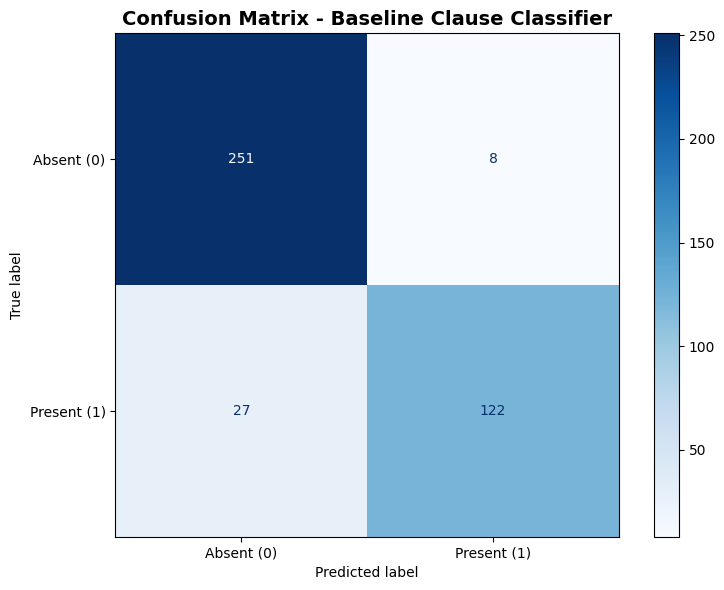


True Negatives:  251  (correctly identified as absent)
False Positives: 8  (incorrectly flagged as present)
False Negatives: 27  (MISSED dangerous clauses!) <- CRITICAL
True Positives:  122  (correctly identified as present)


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absent (0)', 'Present (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Baseline Clause Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}  (correctly identified as absent)")
print(f"False Positives: {fp}  (incorrectly flagged as present)")
print(f"False Negatives: {fn}  (MISSED dangerous clauses!) <- CRITICAL")
print(f"True Positives:  {tp}  (correctly identified as present)")

---
## Phase 6 — Analyze Results

### 6.1 — Per-Label Performance

In [12]:
label_names = df['label_name'].unique()
test_indices = X_test.index

print("=" * 60)
print("PER-LABEL PERFORMANCE BREAKDOWN")
print("=" * 60)

for label in sorted(label_names):
    mask = df.loc[test_indices, 'label_name'] == label
    if mask.sum() == 0:
        continue
    y_true_label = y_test[mask]
    y_pred_label = y_pred[mask.values]

    acc = accuracy_score(y_true_label, y_pred_label)

    if y_true_label.nunique() > 1:
        prec = precision_score(y_true_label, y_pred_label, zero_division=0)
        rec = recall_score(y_true_label, y_pred_label, zero_division=0)
        f1_l = f1_score(y_true_label, y_pred_label, zero_division=0)
    else:
        prec = rec = f1_l = float('nan')

    print(f"\n{label}")
    print(f"  Samples: {mask.sum()}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1_l:.4f}")

PER-LABEL PERFORMANCE BREAKDOWN

Cap On Liability
  Samples: 98
  Accuracy:  0.8980
  Precision: 1.0000
  Recall:    0.8039
  F1-Score:  0.8913

Renewal Term
  Samples: 108
  Accuracy:  0.9259
  Precision: 0.9355
  Recall:    0.8286
  F1-Score:  0.8788

Termination For Convenience
  Samples: 105
  Accuracy:  0.8762
  Precision: 0.9032
  Recall:    0.7368
  F1-Score:  0.8116

Uncapped Liability
  Samples: 97
  Accuracy:  0.9588
  Precision: 0.8889
  Recall:    0.9600
  F1-Score:  0.9231


### 6.2 — Class Imbalance Analysis

In [13]:
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

total = len(df)
pos = (df['target'] == 1).sum()
neg = (df['target'] == 0).sum()
print(f"\nOverall Distribution:")
print(f"  Positive (clause present): {pos} ({pos/total:.1%})")
print(f"  Negative (clause absent):  {neg} ({neg/total:.1%})")
ratio_str = f"1:{neg/pos:.1f}" if pos > 0 else "N/A"
print(f"  Imbalance Ratio: {ratio_str}")

print(f"\nPer-Label Imbalance:")
for label in sorted(label_names):
    sub = df[df['label_name'] == label]
    p = (sub['target'] == 1).sum()
    n = (sub['target'] == 0).sum()
    r = f"1:{n/p:.1f}" if p > 0 else "N/A"
    print(f"  {label:35s}  pos={p:4d}  neg={n:4d}  ratio={r}")

CLASS IMBALANCE ANALYSIS

Overall Distribution:
  Positive (clause present): 745 (36.5%)
  Negative (clause absent):  1295 (63.5%)
  Imbalance Ratio: 1:1.7

Per-Label Imbalance:
  Cap On Liability                     pos= 275  neg= 235  ratio=1:0.9
  Renewal Term                         pos= 176  neg= 334  ratio=1:1.9
  Termination For Convenience          pos= 183  neg= 327  ratio=1:1.8
  Uncapped Liability                   pos= 111  neg= 399  ratio=1:3.6


### 6.3 — Error Analysis (False Positives & False Negatives)

In [14]:
test_df = df.loc[test_indices].copy()
test_df['predicted'] = y_pred
test_df['actual'] = y_test.values

false_negatives = test_df[(test_df['actual'] == 1) & (test_df['predicted'] == 0)]
false_positives = test_df[(test_df['actual'] == 0) & (test_df['predicted'] == 1)]

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(f"\nFalse Negatives (MISSED clauses): {len(false_negatives)}")
print("  These are dangerous -- the model failed to detect present clauses!")
if len(false_negatives) > 0:
    print(f"\n  Breakdown by label:")
    print(false_negatives['label_name'].value_counts().to_string())

print(f"\nFalse Positives (false alarms): {len(false_positives)}")
if len(false_positives) > 0:
    print(f"\n  Breakdown by label:")
    print(false_positives['label_name'].value_counts().to_string())

ERROR ANALYSIS

False Negatives (MISSED clauses): 27
  These are dangerous -- the model failed to detect present clauses!

  Breakdown by label:
label_name
Termination For Convenience    10
Cap On Liability               10
Renewal Term                    6
Uncapped Liability              1

False Positives (false alarms): 8

  Breakdown by label:
label_name
Termination For Convenience    3
Uncapped Liability             3
Renewal Term                   2


### 6.4 — Top Predictive Features

In [15]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_n = 15
top_positive_idx = np.argsort(coefficients)[-top_n:][::-1]
top_negative_idx = np.argsort(coefficients)[:top_n]

print("=" * 60)
print("TOP PREDICTIVE FEATURES")
print("=" * 60)

print(f"\nTop {top_n} features indicating CLAUSE PRESENT (target=1):")
for i in top_positive_idx:
    fname = feature_names[i]
    print(f"  {fname:30s}  coef={coefficients[i]:.4f}")

print(f"\nTop {top_n} features indicating CLAUSE ABSENT (target=0):")
for i in top_negative_idx:
    fname = feature_names[i]
    print(f"  {fname:30s}  coef={coefficients[i]:.4f}")

TOP PREDICTIVE FEATURES

Top 15 features indicating CLAUSE PRESENT (target=1):
  liability                       coef=3.8958
  damages                         coef=3.8559
  term                            coef=3.2667
  termination                     coef=2.5745
  agreement                       coef=2.5648
  notice                          coef=2.5479
  terminate                       coef=2.4657
  section                         coef=2.3426
  written notice                  coef=2.3372
  party                           coef=2.2756
  consequential                   coef=2.0601
  loss                            coef=1.9012
  liable                          coef=1.8500
  terminate agreement             coef=1.7758
  written                         coef=1.7270

Top 15 features indicating CLAUSE ABSENT (target=0):
  waiver                          coef=-0.6381
  company                         coef=-0.6241
  power                           coef=-0.5613
  arbitration                     co

### 6.5 — Summary & Recommendations

In [16]:
summary = f'''
================================================================
BASELINE MODEL SUMMARY
================================================================

Model:          Logistic Regression
Vectorizer:     TF-IDF (max_features=10000, ngram_range=(1,2))
Train/Test:     80/20 split (stratified)

RESULTS:
  Accuracy:     {accuracy:.4f}
  Precision:    {precision:.4f}
  Recall:       {recall:.4f}
  F1-Score:     {f1:.4f}

CRITICAL OBSERVATIONS:
  False Negatives (missed clauses): {len(false_negatives)}
  False Positives (false alarms):   {len(false_positives)}

NEXT STEPS:
  1. Text preprocessing (lowercasing, lemmatization, legal stopwords)
  2. Address class imbalance (SMOTE, class weights)
  3. Try other models (SVM, Random Forest, BERT)
  4. Per-label classifiers for better granularity
  5. Cross-validation for robust evaluation
'''
print(summary)


BASELINE MODEL SUMMARY

Model:          Logistic Regression
Vectorizer:     TF-IDF (max_features=10000, ngram_range=(1,2))
Train/Test:     80/20 split (stratified)

RESULTS:
  Accuracy:     0.9142
  Precision:    0.9385
  Recall:       0.8188
  F1-Score:     0.8746

CRITICAL OBSERVATIONS:
  False Negatives (missed clauses): 27
  False Positives (false alarms):   8

NEXT STEPS:
  1. Text preprocessing (lowercasing, lemmatization, legal stopwords)
  2. Address class imbalance (SMOTE, class weights)
  3. Try other models (SVM, Random Forest, BERT)
  4. Per-label classifiers for better granularity
  5. Cross-validation for robust evaluation

